In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df1 = pd.read_csv("../data/api_data_aadhar_demographic_0_500000.csv")
df2 = pd.read_csv("../data/api_data_aadhar_demographic_500000_1000000.csv")
df3 = pd.read_csv("../data/api_data_aadhar_demographic_1000000_1500000.csv")
df4 = pd.read_csv("../data/api_data_aadhar_demographic_1500000_2000000.csv")
df5 = pd.read_csv("../data/api_data_aadhar_demographic_2000000_2071700.csv")

dfTot = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

dfa = pd.read_csv("../data/api_data_aadhar_enrolment_0_500000.csv")
dfb = pd.read_csv("../data/api_data_aadhar_enrolment_500000_1000000.csv")

dfCom = pd.concat([dfa, dfb], ignore_index=True)



In [129]:
def clean_state_names(df, state_col="state"):
    df = df.copy()

    # normalize text
    df[state_col] = (
        df[state_col]
        .astype(str)
        .str.lower()
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)  # fix double spaces
    )

    state_corrections = {
        # old / renamed states
        "orissa": "odisha",
        "uttaranchal": "uttarakhand",
        "pondicherry": "puducherry",

        # UT merger variants
        "andaman & nicobar islands": "andaman and nicobar islands",
        "jammu & kashmir": "jammu and kashmir",
        "dadra & nagar haveli": "dadra and nagar haveli and daman and diu",
        "daman & diu": "dadra and nagar haveli and daman and diu",
        "dadra and nagar haveli": "dadra and nagar haveli and daman and diu",
        "daman and diu": "dadra and nagar haveli and daman and diu",
        "the dadra and nagar haveli and daman and diu":
            "dadra and nagar haveli and daman and diu",

        # misspellings
        "westbengal": "west bengal",
        "west bangal": "west bengal",
        "west bengli": "west bengal",
        "chhatisgarh": "chhattisgarh",

        # cities incorrectly in state column
        "balanagar": "telangana",
        "darbhanga": "bihar",
        "jaipur": "rajasthan",
        "nagpur": "maharashtra",
        "madanapalle": "andhra pradesh",
        "puttenahalli": "karnataka",
        "raja annamalai puram": "tamil nadu",
    }

    df[state_col] = df[state_col].replace(state_corrections)

    # remove numeric junk
    df = df[~df[state_col].str.match(r"^\d+$")]
    df = df[~df[state_col].isin(["0", "1", "2"])]

    # title case
    df[state_col] = df[state_col].str.title()

    return df


In [130]:
dfTot = clean_state_names(dfTot, "state")
dfCom = clean_state_names(dfCom, "state")


In [131]:
dfTot['demo_age_5_17'] = pd.to_numeric(dfTot['demo_age_5_17'], errors='coerce')
dfTot['demo_age_17_'] = pd.to_numeric(dfTot['demo_age_17_'], errors='coerce')

dfTot['total_updates'] = dfTot['demo_age_5_17'] + dfTot['demo_age_17_']

dfTot['adult_update_ratio'] = dfTot['demo_age_17_'] / dfTot['total_updates']

dfTot[['demo_age_5_17', 'demo_age_17_', 'adult_update_ratio']].head()

,demo_age_5_17,demo_age_17_,adult_update_ratio
0,49,529,0.915225
1,22,375,0.944584
2,65,765,0.921687
3,24,314,0.928994
4,45,785,0.945783


State Name Normalization Check (Passed)

After applying a unified state-normalization function to both datasets, the unique state/UT labels in the demographic and enrollment datasets were verified to match exactly.  
All subsequent aggregations and merges are performed only after this validation step to ensure referential consistency.


In [132]:
demo = dfTot[[
    "date", "state", "district", "pincode", "demo_age_5_17"
]]

enroll = dfCom[[
    "date", "state", "district", "pincode", "age_5_17"
]]



In [133]:
for df in [demo, enroll]:
    df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
    df.dropna(subset=["date"], inplace=True)



C:\Users\madhu\AppData\Local\Temp\ipykernel_17636\683535146.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")
C:\Users\madhu\AppData\Local\Temp\ipykernel_17636\683535146.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=["date"], inplace=True)
C:\Users\madhu\AppData\Local\Temp\ipykernel_17636\683535146.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

In [134]:
demo_agg = (
    demo.groupby(["state", "district", "pincode"])["demo_age_5_17"]
    .sum()
    .reset_index()
)

enroll_agg = (
    enroll.groupby(["state", "district", "pincode"])["age_5_17"]
    .sum()
    .reset_index()
)

merged = pd.merge(
    demo_agg,
    enroll_agg,
    on=["state", "district", "pincode"],
    how="inner"
)

merged["enrollment_ratio"] = (
    merged["age_5_17"] / merged["demo_age_5_17"]
)



The demographic and enrollment datasets differ in their age-group definitions.  
To ensure methodological consistency and avoid biased comparisons, integration was restricted to the 5–17 age group, which is the only cohort with directly comparable definitions across both datasets.

The Demographic dataset provides:
  - `demo_age_5_17` (population aged 5–17)
  - `demo_age_17_` (population aged 17 and above)

The Enrollment dataset provides:
  - `age_0_5`
  - `age_5_17`
  - `age_18_`

The 5–17 cohort was selected because it aligns exactly in both datasets and represents the school-age population most relevant to enrollment analysis.  
Other age groups (0–5 and 18+) were excluded from integrated ratio-based analysis due to incompatible age boundaries, which could otherwise introduce structural bias.

All enrollment gap metrics and risk scores in this notebook therefore refer exclusively to the 5–17 age group.


In [135]:
state_enroll_gap = (
    merged.groupby("state")[["demo_age_5_17", "age_5_17"]]
    .sum()
)

state_enroll_gap["enrollment_ratio"] = (
    state_enroll_gap["age_5_17"] /
    state_enroll_gap["demo_age_5_17"]
)

state_enroll_gap.sort_values("enrollment_ratio").head()



,demo_age_5_17,age_5_17,enrollment_ratio
state,,,
Chandigarh,13133,211,0.016066
Himachal Pradesh,19403,653,0.033655
Andhra Pradesh,320823,12903,0.040218
Puducherry,4694,193,0.041116
Andaman And Nicobar Islands,609,32,0.052545


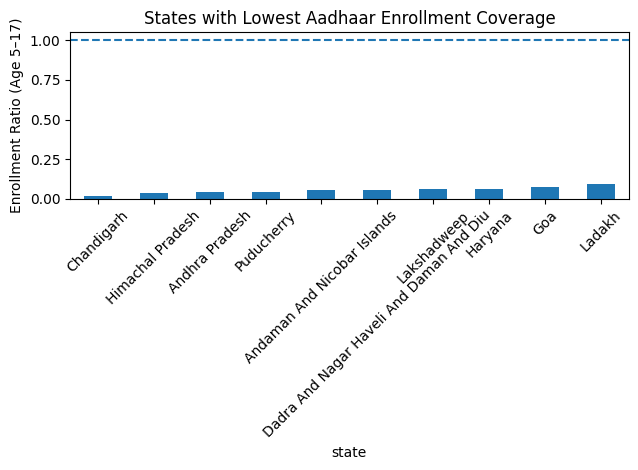

In [136]:
plt.figure()
state_enroll_gap["enrollment_ratio"].sort_values().head(10).plot(kind="bar")
plt.axhline(1, linestyle="--")
plt.ylabel("Enrollment Ratio (Age 5–17)")
plt.title("States with Lowest Aadhaar Enrollment Coverage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [137]:
state_enroll_gap["risk_score"] = (
    (1 - state_enroll_gap["enrollment_ratio"]) *
    state_enroll_gap["demo_age_5_17"]
)

state_enroll_gap.sort_values("risk_score", ascending=False).head(10)


,demo_age_5_17,age_5_17,enrollment_ratio,risk_score
state,,,,
Uttar Pradesh,790199,466251,0.590043,323948.0
Andhra Pradesh,320823,12903,0.040218,307920.0
Madhya Pradesh,407047,112834,0.277201,294213.0
Tamil Nadu,315543,36499,0.115670,279044.0
Karnataka,264895,25527,0.096366,239368.0
Telangana,242127,23670,0.097759,218457.0
Maharashtra,273103,81039,0.296734,192064.0
West Bengal,242438,79868,0.329437,162570.0
Delhi,175535,21101,0.120210,154434.0


In [138]:
merged["risk_score"] = (
    (1 - merged["enrollment_ratio"]) *
    merged["demo_age_5_17"]
)


In [139]:
top_risk_pincodes = (
    merged.sort_values("risk_score", ascending=False)
    .head(10)
)

top_risk_pincodes


,state,district,pincode,demo_age_5_17,age_5_17,enrollment_ratio,risk_score
5467,Delhi,North East Delhi,110094,18060,2463,0.136379,15597.0
5545,Delhi,West Delhi,110059,11402,2395,0.210051,9007.0
7083,Haryana,Faridabad,121004,8823,1567,0.177604,7256.0
7272,Haryana,Panipat,132103,7663,470,0.061334,7193.0
5482,Delhi,North West Delhi,110086,7494,471,0.062850,7023.0
5446,Delhi,East Delhi,110092,8020,1206,0.150374,6814.0
5542,Delhi,West Delhi,110041,7204,629,0.087313,6575.0
5450,Delhi,East Delhi,110096,6484,223,0.034392,6261.0
5459,Delhi,North Delhi,110084,6220,373,0.059968,5847.0
5501,Delhi,South Delhi,110044,5792,368,0.063536,5424.0


In [140]:
state_enroll_gap.to_csv("../outputs/state_enrollment_gap_clean.csv")
top_risk_pincodes.to_csv("../outputs/top_risk_pincodes.csv", index=False)


In [141]:
total_children = merged["demo_age_5_17"].sum()
total_enrolled = merged["age_5_17"].sum()

overall_coverage = total_enrolled / total_children
overall_coverage


np.float64(0.3405901499605887)

In [142]:
state_enroll_gap.sort_values("risk_score", ascending=False).head(10)


,demo_age_5_17,age_5_17,enrollment_ratio,risk_score
state,,,,
Uttar Pradesh,790199,466251,0.590043,323948.0
Andhra Pradesh,320823,12903,0.040218,307920.0
Madhya Pradesh,407047,112834,0.277201,294213.0
Tamil Nadu,315543,36499,0.115670,279044.0
Karnataka,264895,25527,0.096366,239368.0
Telangana,242127,23670,0.097759,218457.0
Maharashtra,273103,81039,0.296734,192064.0
West Bengal,242438,79868,0.329437,162570.0
Delhi,175535,21101,0.120210,154434.0


In [143]:
state_spread = (
    merged.groupby("state")["enrollment_ratio"]
    .std()
    .sort_values(ascending=False)
)

state_spread.head(10)


state
Arunachal Pradesh                           0.534728
Tripura                                     0.358030
Ladakh                                      0.300754
Puducherry                                  0.285746
Himachal Pradesh                            0.257717
Lakshadweep                                 0.217013
Goa                                         0.216986
Dadra And Nagar Haveli And Daman And Diu    0.046102
Chandigarh                                  0.032363
Andaman And Nicobar Islands                      NaN
Name: enrollment_ratio, dtype: float64

In [144]:
top_risk_pincodes = merged.sort_values("risk_score", ascending=False).head(10)
top_risk_pincodes


,state,district,pincode,demo_age_5_17,age_5_17,enrollment_ratio,risk_score
5467,Delhi,North East Delhi,110094,18060,2463,0.136379,15597.0
5545,Delhi,West Delhi,110059,11402,2395,0.210051,9007.0
7083,Haryana,Faridabad,121004,8823,1567,0.177604,7256.0
7272,Haryana,Panipat,132103,7663,470,0.061334,7193.0
5482,Delhi,North West Delhi,110086,7494,471,0.062850,7023.0
5446,Delhi,East Delhi,110092,8020,1206,0.150374,6814.0
5542,Delhi,West Delhi,110041,7204,629,0.087313,6575.0
5450,Delhi,East Delhi,110096,6484,223,0.034392,6261.0
5459,Delhi,North Delhi,110084,6220,373,0.059968,5847.0
5501,Delhi,South Delhi,110044,5792,368,0.063536,5424.0


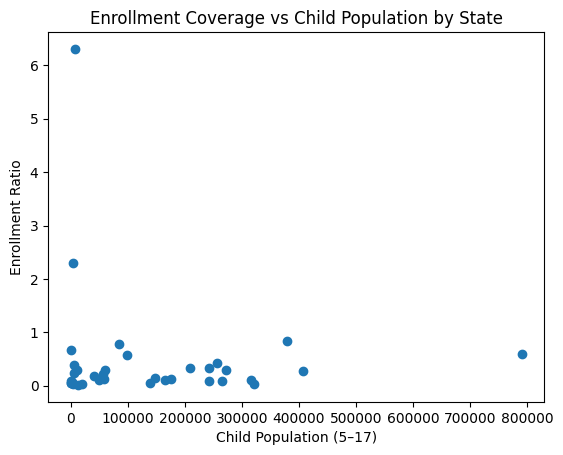

In [145]:
plt.figure()
plt.scatter(
    state_enroll_gap["demo_age_5_17"],
    state_enroll_gap["enrollment_ratio"]
)
plt.xlabel("Child Population (5–17)")
plt.ylabel("Enrollment Ratio")
plt.title("Enrollment Coverage vs Child Population by State")
plt.show()


Enrollment Coverage vs Population Size

The scatter plot highlights that Aadhaar enrollment coverage among children aged 5–17 does not scale linearly with population size. While low enrollment ratios are observed across both large states and small Union Territories, regions with large child populations and low coverage represent the highest absolute enrollment risk. Outliers with enrollment ratios exceeding 1 occur primarily in low-population regions and likely reflect migration and timing effects between population estimates and enrollment activity. This reinforces the need for population-weighted prioritization rather than reliance on coverage ratios alone.


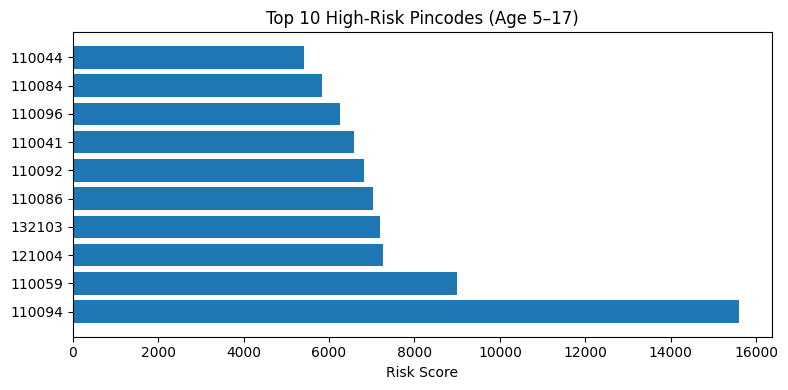

In [146]:
plt.figure(figsize=(8,4))
plt.barh(
    top_risk_pincodes["pincode"].astype(str),
    top_risk_pincodes["risk_score"]
)
plt.xlabel("Risk Score")
plt.title("Top 10 High-Risk Pincodes (Age 5–17)")
plt.tight_layout()
plt.show()


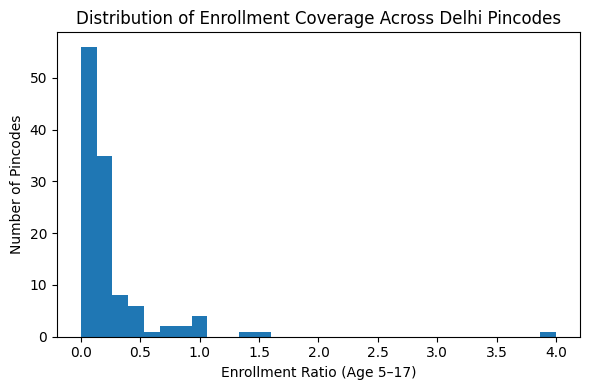

In [147]:
delhi_data = merged[merged["state"] == "Delhi"]

delhi_valid = delhi_data[
    np.isfinite(delhi_data["enrollment_ratio"])
]

plt.figure(figsize=(6,4))
plt.hist(delhi_valid["enrollment_ratio"], bins=30)
plt.xlabel("Enrollment Ratio (Age 5–17)")
plt.ylabel("Number of Pincodes")
plt.title("Distribution of Enrollment Coverage Across Delhi Pincodes")
plt.tight_layout()
plt.show()


Distribution of Enrollment Coverage Across Delhi Pincodes (Age 5–17)

This histogram shows the distribution of Aadhaar enrollment coverage across pincodes within Delhi. For visualization purposes, pincodes with non-finite enrollment ratios (arising from zero reported child population) were excluded, as such values distort the scale without providing meaningful information.

The distribution exhibits a wide spread, indicating substantial intra-state variation in enrollment coverage. Several pincodes cluster at very low enrollment ratios, highlighting localized pockets of severe under-enrollment** within an otherwise highly urbanized region. This reinforces the finding that state-level averages mask operationally significant disparities and that pincode-level targeting is necessary for effective enrollment interventions.
